In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import re

# ==========================
# Conexión a la página
# ==========================

url = "https://books.toscrape.com/"
response = requests.get(url)

print(f"Verificación del request: {response.status_code}")
# una salida 200 indica que el request fue exitoso

print(f"URL consultada: {response.url}")
print(f"Content-Type recibido: {response.headers.get('Content-Type')}")


Verificación del request: 200
URL consultada: https://books.toscrape.com/
Content-Type recibido: text/html


In [2]:

# ==========================
# Parsear el HTML
# ==========================

soup = BeautifulSoup(response.text, "html.parser")

# Lista donde se almacenarán los datos
datos = []

# Menú de categorías
menu = soup.find("ul", class_="nav nav-list")

# Recorrer todas las categorías (excepto Books)
for categoria in menu.find_all("a")[1:]:

    href = categoria["href"]

    # Expresión regular para extraer el nombre de la categoría
    patron = re.search(r'category/books/(.*?)_\d+', href)

    if patron:
        nombre_categoria = patron.group(1)
        nombre_categoria = nombre_categoria.replace("-", " ").title()
    else:
        nombre_categoria = categoria.text.strip()

    # URL completa de la categoría
    url_categoria = url + href

    # Solicitar la página de la categoría
    response_categoria = requests.get(url_categoria)
    soup_categoria = BeautifulSoup(response_categoria.text, "html.parser")

    # Contar libros de la categoría
    frecuencia = len(
        soup_categoria.find_all("article", class_="product_pod")
    )

    # Guardar datos
    datos.append({
        "Categoria": nombre_categoria,
        "Frecuencia": frecuencia
    })

# ==========================
# Crear DataFrame
# ==========================

df_categorias = pd.DataFrame(datos)

print(df_categorias)

# Mostrar primeras filas
print("\nPrimeros registros:")
print(df_categorias.head())


             Categoria  Frecuencia
0               Travel          11
1              Mystery          20
2   Historical Fiction          20
3       Sequential Art          20
4             Classics          19
5           Philosophy          11
6              Romance          20
7       Womens Fiction          17
8              Fiction          20
9            Childrens          20
10            Religion           7
11          Nonfiction          20
12               Music          13
13             Default          20
14     Science Fiction          16
15    Sports And Games           5
16       Add A Comment          20
17             Fantasy          20
18           New Adult           6
19         Young Adult          20
20             Science          14
21              Poetry          19
22          Paranormal           1
23                 Art           8
24          Psychology           7
25       Autobiography           9
26           Parenting           1
27       Adult Ficti

Interpretación del resultado:
El gráfico de barras horizontales permite identificar con precisión qué temáticas o categorías literarias tienen una mayor presencia inicial dentro del catálogo de 'BookAnalytics'. Al visualizar las frecuencias de manera descendente, el equipo comercial puede descubrir de un vistazo qué nichos de mercado están más saturados de títulos (por ejemplo, aquellos con el tope de 20 libros por página) y cuáles cuentan con menor stock visible, facilitando la toma de decisiones estratégicas para la adquisición de nuevos libros.

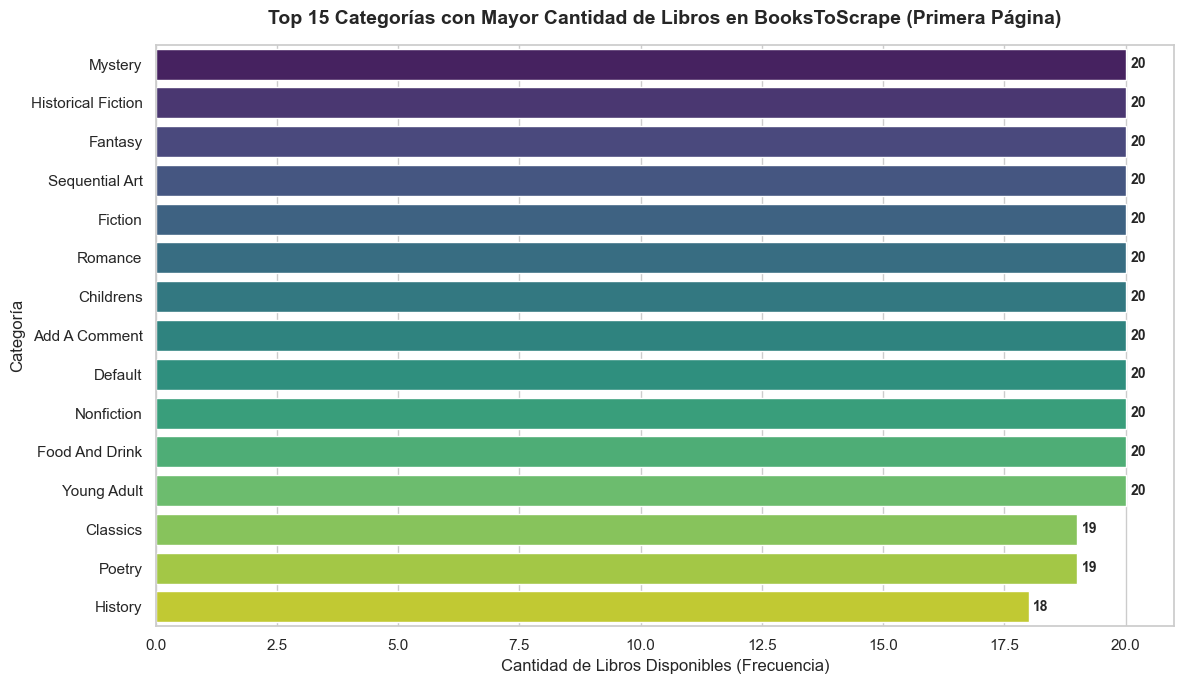

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ordenar el DataFrame de mayor a menor frecuencia y tomar las primeras 15 categorías
df_top_categorias = df_categorias.sort_values(by="Frecuencia", ascending=False).head(15)

# Configurar el estilo del gráfico
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

# Crear gráfico de barras horizontales (ideal para nombres largos de categorías)
bar_plot = sns.barplot(
    x="Frecuencia", 
    y="Categoria", 
    data=df_top_categorias, 
    palette="viridis",
    hue="Categoria",
    legend=False
)

# Añadir los valores numéricos al final de cada barra para mayor claridad
for index, value in enumerate(df_top_categorias["Frecuencia"]):
    plt.text(value + 0.1, index, str(value), va="center", fontsize=10, fontweight="bold")

# Personalizar títulos y etiquetas
plt.title("Top 15 Categorías con Mayor Cantidad de Libros en BooksToScrape (Primera Página)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Cantidad de Libros Disponibles (Frecuencia)", fontsize=12)
plt.ylabel("Categoría", fontsize=12)
plt.tight_layout()

# Mostrar el gráfico
plt.show()